# Real Audio: `sample_uk.opus`

This notebook loads `notebooks/sample_uk.opus`, decodes it to mono 16 kHz PCM with `ffmpeg`, then runs the Python extension on real audio.

> Setup from the repository root:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```
>
> This notebook also requires the `ffmpeg` command-line tool because the sample is Opus encoded.


In [1]:
from __future__ import annotations

import array
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import spafe


In [2]:
def find_sample() -> Path:
    candidates = [
        Path("notebooks/sample_uk.opus"),
        Path("sample_uk.opus"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Could not find notebooks/sample_uk.opus")


def decode_opus_mono(path: Path, fs: int = 16_000) -> list[float]:
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("Install ffmpeg to decode Opus audio for this notebook")
    command = [
        "ffmpeg",
        "-v",
        "error",
        "-i",
        str(path),
        "-ac",
        "1",
        "-ar",
        str(fs),
        "-f",
        "f32le",
        "pipe:1",
    ]
    raw = subprocess.run(command, check=True, capture_output=True).stdout
    samples = array.array("f")
    samples.frombytes(raw)
    return samples.tolist()


sample_path = find_sample()
fs = 16_000
signal = decode_opus_mono(sample_path, fs=fs)
duration = len(signal) / fs
print(f"loaded {sample_path} -> {len(signal)} mono samples at {fs} Hz ({duration:.2f} s)")


loaded sample_uk.opus -> 374720 mono samples at 16000 Hz (23.42 s)


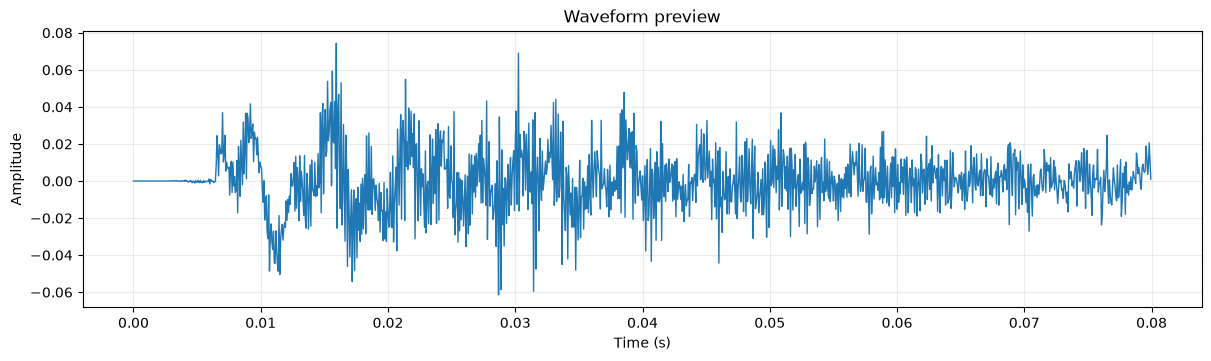

In [3]:
preview_seconds = 0.08
preview = signal[: int(preview_seconds * fs)]
preview_time = [idx / fs for idx in range(len(preview))]

fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
ax.plot(preview_time, preview, linewidth=1.0)
ax.set_title("Waveform preview")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True, alpha=0.25)
plt.show()


## Cepstral Features and Spectrogram

The sample is short enough to process directly, but the feature options below keep the notebook responsive.

In [4]:
feature_signal = signal[: min(len(signal), fs * 12)]
opts = spafe.FeatureOptions(
    fs=fs,
    nfft=512,
    nfilts=32,
    num_ceps=13,
    win_len=0.025,
    win_hop=0.010,
    normalize="mean_subtraction",
)

mfcc = spafe.mfcc(feature_signal, opts)
pncc = spafe.pncc(feature_signal, opts)
mel_spec = spafe.mel_spectrogram(feature_signal, opts)

print(f"MFCC shape: {len(mfcc)} x {len(mfcc[0])}")
print(f"PNCC shape: {len(pncc)} x {len(pncc[0])}")
print(f"Mel spectrogram shape: {len(mel_spec.features)} x {len(mel_spec.features[0])}")


MFCC shape: 1198 x 13
PNCC shape: 1198 x 13
Mel spectrogram shape: 1198 x 32


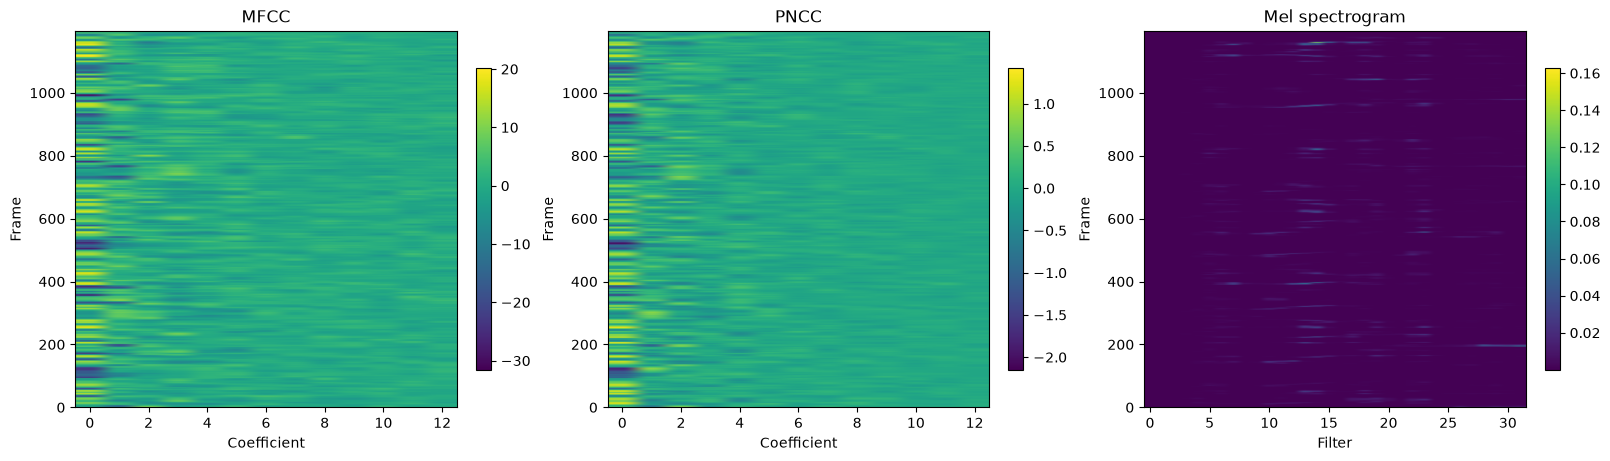

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, matrix, title, xlabel in [
    (axes[0], mfcc, "MFCC", "Coefficient"),
    (axes[1], pncc, "PNCC", "Coefficient"),
    (axes[2], mel_spec.features, "Mel spectrogram", "Filter"),
]:
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()


## Pitch Tracking

YIN estimates a fundamental-frequency track, while the dominant-frequency helper reports the strongest FFT-bin frequency per frame.

In [6]:
pitch_signal = signal[: min(len(signal), fs * 8)]
pitches, harmonic_rates, argmins, times = spafe.compute_yin(
    pitch_signal,
    fs=fs,
    win_len=0.03,
    win_hop=0.015,
    low_freq=50.0,
    high_freq=600.0,
    harmonic_threshold=0.1,
)
dominant = spafe.get_dominant_frequencies(
    pitch_signal,
    fs=fs,
    nfft=512,
    win_len=0.025,
    win_hop=0.010,
)
dominant_times = [idx * 0.010 for idx in range(len(dominant))]
voiced = [pitch for pitch in pitches if pitch > 0.0]
print(f"YIN frames: {len(pitches)}")
print(f"average voiced pitch: {sum(voiced) / len(voiced):.2f} Hz" if voiced else "no voiced frames")


YIN frames: 532
average voiced pitch: 137.40 Hz


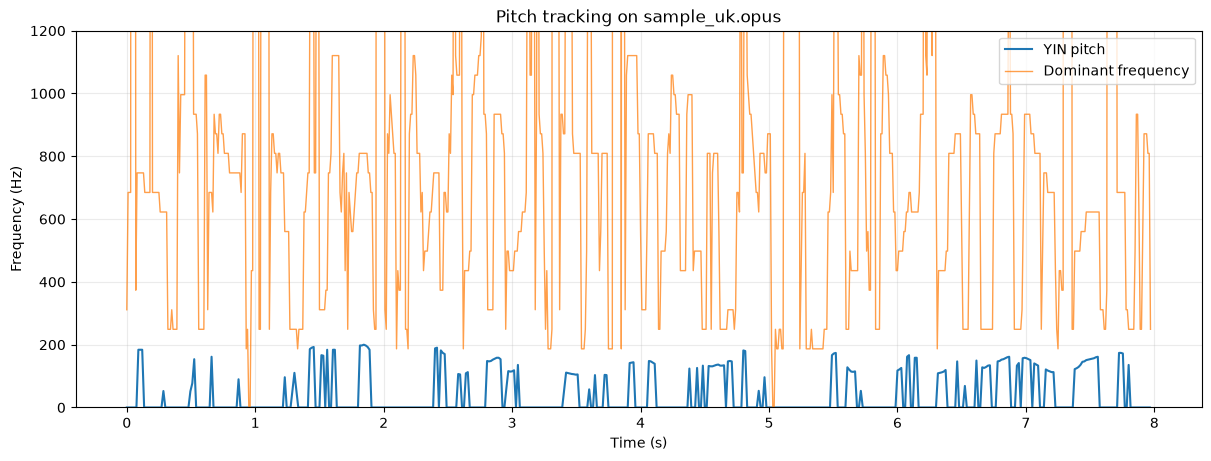

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(times, pitches, label="YIN pitch", linewidth=1.5)
ax.plot(dominant_times, dominant, label="Dominant frequency", linewidth=1.0, alpha=0.75)
ax.set_title("Pitch tracking on sample_uk.opus")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(0, 1200)
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## Cochleagram and Spectral Descriptors

In [8]:
coch_signal_size = min(8192, len(signal))
coch_opts = spafe.CochleagramOptions(
    signal_size=coch_signal_size,
    sr=fs,
    env_sr=400,
    filter_n=16,
    low_lim=50.0,
    high_lim=6000.0,
    sample_factor=2,
    downsampling_window_size=129,
    compression="power",
)
coch = spafe.cochleagram(signal[:coch_signal_size], coch_opts)
print(f"cochleagram shape: {len(coch.cochleagram)} x {len(coch.cochleagram[0])}")
print("first center frequencies:", [round(value, 1) for value in coch.center_freqs[:8]])


cochleagram shape: 37 x 202
first center frequencies: [25.7, 50.0, 76.7, 105.9, 137.9, 173.0, 211.5, 253.6]


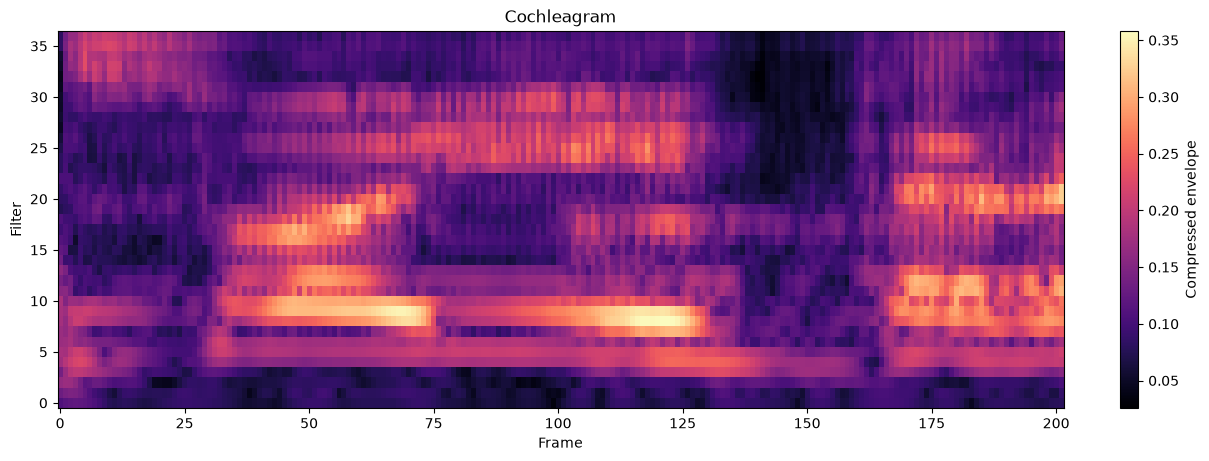

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
image = ax.imshow(coch.cochleagram, aspect="auto", origin="lower", cmap="magma")
ax.set_title("Cochleagram")
ax.set_xlabel("Frame")
ax.set_ylabel("Filter")
fig.colorbar(image, ax=ax, label="Compressed envelope")
plt.show()


In [10]:
descriptors = spafe.extract_feats(feature_signal, fs, nfft=512)
print(f"spectral centroid: {descriptors.spectral_centroid:.2f}")
print(f"spectral entropy: {descriptors.spectral_entropy:.4f}")
print(f"spectral flatness: {descriptors.spectral_flatness:.6f}")
print(f"spectral flux: {descriptors.spectral_flux:.4f}")


spectral centroid: 3499.02
spectral entropy: 9.6505
spectral flatness: 0.563721
spectral flux: 5.1470
